# Evaluate Performance for Different Model Sizes

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from index_FlatL2 import IndexFlatL2
from index_IVFFlat import IndexIVFFlat
from index_PQ import IndexPQ

In [ ]:
flat = IndexFlatL2()
ivf_flat = IndexIVFFlat()
pq = IndexPQ()

In [ ]:
# define the test set
test_embeddings = np.load("100K_embeddings/subset_7/embeddings.npy")
# shuffle the dataset
np.random.shuffle(test_embeddings)
test_embeddings = test_embeddings[:N_QUERIES,:]

In [46]:
N_QUERIES = 100
K = 5
NUM_BATCHES = 5

"""Compute the sum of distances between the query and the top K search results for an index"""
def get_cost(query_emb, query_result):
    cost = [np.sum((query_emb - flat.embed_text(x['Content']))**2) for x in query_result['Content']]
    return np.sum(cost)

# define variables to hold the data
flat_times = []
ivf_flat_times = []
pq_times = []
flat_scores = []
ivf_flat_scores = []
pq_scores = []
random_scores = []

for batch_num in range(NUM_BATCHES):
    # add more files to each index
    flat.create(f"100K_embeddings/subset_{batch_num}", "indexes/flat")
    ivf_flat.create(f"100K_embeddings/subset_{batch_num}", "indexes/ivf_flat")
    pq.create(f"100K_embeddings/subset_{batch_num}", "indexes/pq")
    if batch_num == 0:
        all_embeddings = np.load("100K_embeddings/subset_0/embeddings.npy")
    else:
        all_embeddings = np.vstack((all_embeddings, np.load(f"100K_embeddings/subset_{batch_num}/embeddings.npy")))

    # get the results
    flat_results = [flat.query_embedding(test_embeddings[i,:][np.newaxis,:], K) for i in range(N_QUERIES)]
    ivf_flat_results = [ivf_flat.query_embedding(test_embeddings[i,:][np.newaxis,:], K) for i in range(N_QUERIES)]
    pq_results = [pq.query_embedding(test_embeddings[i,:][np.newaxis,:], K) for i in range(N_QUERIES)]

    # record the amount of time taken
    flat_times.append(np.mean([x['Time'] for x in flat_results]))
    ivf_flat_times.append(np.mean([x['Time'] for x in ivf_flat_results]))
    pq_times.append(np.mean([x['Time'] for x in pq_results]))

    # record the costs of the flat index
    flat_costs = np.array([np.sum([x['Score'] for x in query['Content']]) for query in flat_results])
    ivf_flat_costs = np.array([get_cost(test_embeddings[i], ivf_flat_results[i]) for i in range(N_QUERIES)])
    pq_costs = np.array([get_cost(test_embeddings[i], pq_results[i]) for i in range(N_QUERIES)])
    random_costs = np.array([np.sum([np.sum((all_embeddings[np.random.randint(0, len(all_embeddings))] - test_embeddings[i])**2) for _ in range(K)]) for i in range(N_QUERIES)])

    # record the scores
    flat_scores.append(0)
    ivf_flat_scores.append(np.mean(ivf_flat_costs - flat_costs))
    pq_scores.append(np.mean(pq_costs - flat_costs))
    random_scores.append(np.mean(random_costs - flat_costs))

    # print the scores and the times
    print(f"Flat score is {flat_scores[batch_num]}")
    print(f"IVF Flat score is {ivf_flat_scores[batch_num]}")
    print(f"PQ score is {pq_scores[batch_num]}")
    print(f"Random score is {random_scores[batch_num]}")
    print('')
    print(f"Flat time is {flat_times[batch_num]}")
    print(f"IVF Flat time is {ivf_flat_times[batch_num]}")
    print(f"PQ time is {pq_times[batch_num]}")

Index does not exist
Number of docs in .faiss file: 482414
Number of docs in .pkl file: 482414
File size: 2963951.661 KB
Time to create index: 20.8678 seconds
Index does not exist
Number of docs in .faiss file: 482414
Number of docs in .pkl file: 482414
File size: 2968204.795 KB
Time to create index: 20.7784 seconds
Index does not exist
Number of docs in .faiss file: 482414
Number of docs in .pkl file: 482414
File size: 5432.262 KB
Time to create index: 31.4048 seconds
Flat score is 0
IVF Flat score is 0.07439315857831601
PQ score is 0.512692888722732
Random score is 1.540677274926273

Flat time is 0.17283944368362428
IVF Flat time is 0.003270587921142578
PQ time is 0.001666090488433838
Index exists
Number of docs in .faiss file: 987616
Number of docs in .pkl file: 987616
File size: 6067912.749 KB
Time to create index: 43.2628 seconds
Index exists
Number of docs in .faiss file: 987616
Number of docs in .pkl file: 987616
File size: 6076207.499 KB
Time to create index: 67.5268 seconds
In

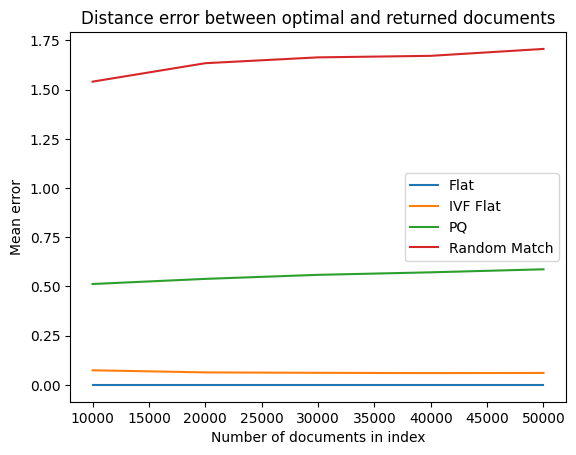

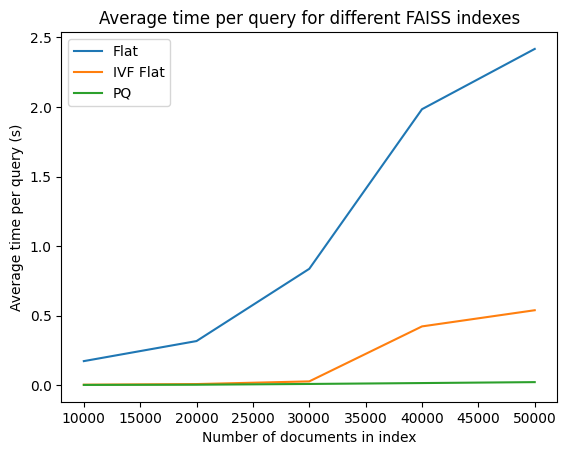

In [57]:
num_documents = np.array(range(1,NUM_BATCHES+1))*10000
plt.plot(num_documents, flat_scores, label='Flat')
plt.plot(num_documents, ivf_flat_scores, label='IVF Flat')
plt.plot(num_documents, pq_scores, label='PQ')
plt.plot(num_documents, random_scores, label='Random Match')
plt.title("Distance error between optimal and returned documents")
plt.xlabel("Number of documents in index")
plt.ylabel("Mean error")
plt.legend()
plt.show()

plt.plot(num_documents, flat_times, label='Flat')
plt.plot(num_documents, ivf_flat_times, label='IVF Flat')
plt.plot(num_documents, pq_times, label='PQ')
plt.title("Average time per query for different FAISS indexes")
plt.xlabel("Number of documents in index")
plt.ylabel("Average time per query (s)")
plt.legend()
plt.show()

In [54]:
# save the data to reproduce the plots later
experiment_data = np.array([flat_times, ivf_flat_times, pq_times, flat_scores, ivf_flat_scores, pq_scores, random_scores])
np.save("experiment_data.npy", experiment_data)